## Notebook 8 — Which single WBM AET method should we use nationwide?

Earlier notebooks compared WBM AET variants against OpenET and flux towers,
but only ever reported **in-sample** stats for the calibrated Oudin run —
notebook 04 fits its PET-multiplier using the *same* years it's then scored
against, which flatters calibration and doesn't tell us how a calibrated
method performs on data it hasn't seen. This notebook fixes that and answers
the actual question we care about: **out of the methods available, which
ONE should the WBM use nationwide** (not the best method per site or per
ecosystem — that's a possible future refinement, not this notebook's job).

**Six candidates, benchmarked against OpenET (4 km gridcell ensemble) and
flux tower ET:**
1. **Oudin, default** — temperature-only, uncalibrated (`PET_mult = 1.0`).
2. **Oudin, per-site calibrated** — notebook 04's per-site PET-multiplier fit.
3. **Oudin, per-ecosystem calibrated** — notebook 04's pooled, one-multiplier-
   per-ecosystem fit.
4. **Penman-Monteith, default** — needs real wind speed, uncalibrated
   (`Kc = 1.0`, per notebook 06's banner).
5. **Penman-Monteith, per-site calibrated** — notebook 07's per-site `Kc` fit
   (new in this pass).
6. **Penman-Monteith, per-ecosystem calibrated** — notebook 07's pooled,
   one-`Kc`-per-ecosystem fit (new in this pass).

Variants 2/3 and 5/6 are mechanically the same calibration approach applied
to two different PET formulations — `wbm.nps_wbm()`'s `pet_mult` argument
scales Oudin's PET directly and *is* Penman-Monteith's crop coefficient
`Kc` (see notebook 07's banner), so both PET methods now get an equal
chance to close their gap with OpenET.

**Held-out evaluation.** Notebooks 04 and 07 both fit their calibrated
variants using only 2016–2021 (`CAL_START`–`CAL_END`); every metric and
figure in *this* notebook is restricted to the 2022–2023 held-out test
period (`TEST_START`–`TEST_END`) that no calibration ever saw. This means
the calibrated variants' scores here reflect genuine out-of-sample skill,
not an optimistic in-sample fit — and it puts all six candidates on equal
footing (the uncalibrated variants don't need a train/test split since they
have no free parameters fit to OpenET, but restricting them to the same
test window keeps the comparison apples-to-apples).

**Robustness, not just averages.** For each candidate we report the mean
RMSE across sites *and* the median and worst-decile (90th-percentile) RMSE.
A method that's great on average but occasionally terrible at some sites is
a worse nationwide choice than one that's consistently middling — the
worst-decile number is what surfaces that.

**Why calibrate at all instead of just using Penman-Monteith?** Penman-Monteith
needs wind speed, and GCM-projected wind is highly uncertain and isn't provided
by LOCA2-downscaled CMIP6 output — so a Penman-Monteith-driven WBM, calibrated
or not, can't be scaled to future-climate runs without that input. Oudin only
needs temperature, which LOCA2/CMIP6 does provide, so calibrating Oudin is the
path that stays usable for future-climate projections regardless of what this
notebook finds. Calibrating Penman-Monteith's `Kc` (variants 5/6) answers a
different, narrower question: for *current-condition* assessments where real
wind is available, does a cheap `Kc` calibration close most of Penman-Monteith's
remaining gap with calibrated Oudin? If so, that strengthens the case for
Penman-Monteith wherever wind data exists; either way it doesn't change the
future-climate calculus above.

**Why condensed figures instead of one panel per site?** This notebook runs
against the full nationwide flux tower list (~80+ sites, see notebook 01's
banner), not just the ~35 sites near National Parks — faceting every site
individually stops being readable at that scale. The park-proximity subset
still gets full per-site facets in notebook 09, which filters these same
cached results down to the ~35 sites within 50 km of a park.

**A data-coverage wrinkle in the held-out design:** almost none of the
flux tower records in this dataset extend into 2022–2023 (checked: 1 of 81
sites has any flux-tower data past 2021), so restricting the vs-flux
comparison to the held-out test period the way we restrict vs-OpenET would
leave that comparison almost empty. Flux tower ET was never the calibration
target in notebooks 04/07 (OpenET was), so there's no leakage risk in scoring
it on the full 2016–2023 record instead — that's what this notebook does:
**vs-OpenET metrics are held-out (test period only); vs-flux metrics use the
full period.** Keep that asymmetry in mind when comparing the two sets of
numbers side by side.

**Scope / assumptions:**
- OpenET only reports actual ET, not a PET-equivalent, so the comparison here
  is AET vs. OpenET only (PET itself is already compared directly between
  Oudin and Penman-Monteith in notebook 06).
- This notebook only reads cached CSVs — it doesn't run the WBM or touch
  Earth Engine.
- Both PM-calibrated variants inherit notebook 07's vapor-pressure caveat
  (`e_a = e_tmin` fallback, no gridMET relative humidity yet) — see notebook
  07's banner for what that means for interpreting their `Kc` values.

**Prerequisites:** run notebooks 01→2→3 at least once (default Oudin WBM run,
OpenET, and gridMET climate caches), notebook 04 at least once with its
per-site *and* per-ecosystem calibration cells (`Data/gridmet_cache/wbm_monthly_site_cal_*.csv`
and `wbm_monthly_ecosystem_cal_*.csv`), notebook 06 at least once
(Penman-Monteith WBM cache: `Data/gridmet_cache/wbm_results_penman_monteith.csv`),
and notebook 07 at least once with its per-site *and* per-ecosystem `Kc`
calibration cells (`Data/gridmet_cache/wbm_monthly_site_cal_pm_*.csv` and
`wbm_monthly_ecosystem_cal_pm_*.csv`).

# Setup Workspace

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines

pd.set_option("display.width", 120)
print("Imports OK -- this notebook only reads cached CSVs, no GEE/raster access needed.")


Imports OK -- this notebook only reads cached CSVs, no GEE/raster access needed.


### Load cached prerequisites (notebooks 02, 03, 04, 06, 07)

In [2]:
# ── Load cached outputs from notebooks 02 (OpenET), 03 (Oudin WBM run), 04
# (calibrated Oudin variants), 06 (Penman-Monteith WBM run), and 07
# (calibrated Penman-Monteith variants) -- no GEE or raster access needed
# here. ────────────────────────────────────────────────────────────────────
flux_towers = pd.read_csv("../Data/geo_data/flux_towers.csv")

openet_gridcell_df = pd.read_csv(
    "../Data/open_et_gridcell/openet_gridcell_timeseries.csv",
    parse_dates=["date"]
)

wbm_results_oudin = pd.read_csv(
    "../Data/gridmet_cache/wbm_results_flux_towers_2016_2023.csv",
    parse_dates=["date"]
)
wbm_results_pm = pd.read_csv(
    "../Data/gridmet_cache/wbm_results_penman_monteith.csv",
    parse_dates=["date"]
)

# Both WBM caches were produced with the repo's default TO_INCHES = True (see
# the "global model settings" cell in notebooks 03/06) -- set here to match,
# so AET can be converted to mm below for comparison against OpenET.
TO_INCHES = True

# Defensive fallback if either cache is missing ecosystem/state (e.g. an older
# cache from before those columns were tagged during the WBM run loop).
for _name in ("wbm_results_oudin", "wbm_results_pm"):
    _df = globals()[_name]
    if "ecosystem" not in _df.columns:
        globals()[_name] = _df.merge(
            flux_towers[["site", "ecosystem", "state"]].drop_duplicates(),
            on="site", how="left"
        )

# flux_monthly isn't cached (it's a cheap local read, no GEE call) — rebuild it
# the same way notebook 04 does, for the timeseries/vs-flux figures below.
flux_frames = []
for row in flux_towers.itertuples():
    fpath = f"../Data/flux_ET_dataset/monthly_data_files/{row.site}_monthly_data.csv"
    if not os.path.exists(fpath):
        continue
    _fdf = pd.read_csv(fpath, parse_dates=["date"])
    _fdf = _fdf[_fdf["date"] >= "2016-01-01"]
    _fdf["site"] = row.site
    flux_frames.append(_fdf)
flux_monthly = (
    pd.concat(flux_frames, ignore_index=True)
    .sort_values(["site", "date"])
    .reset_index(drop=True)
)

# ── Calibration / held-out test split (must match notebooks 04 and 07
# exactly) ────────────────────────────────────────────────────────────────
# Both notebooks fit their calibrated variants using ONLY CAL_START-CAL_END.
# Every metric and figure in *this* notebook is restricted to TEST_START-
# TEST_END, a period no calibration ever saw -- so the calibrated variants'
# scores here reflect genuine out-of-sample skill, not an optimistic in-sample
# fit. If you change this split, re-run notebooks 04 and 07 first (their
# caches are filename-tagged by objective, not by split, so a stale split
# would silently still "match").
CAL_START  = "2016-01-01"
CAL_END    = "2021-12-31"
TEST_START = "2022-01-01"
TEST_END   = "2023-12-31"

# Notebook 04's calibrated Oudin runs -- cached already monthly (with a
# precomputed aet_mm column in mm regardless of TO_INCHES), keyed by whatever
# OBJECTIVE notebook 04 was last run with. Two variants: one PET_mult per
# site, and one PET_mult per ecosystem (pooled fit).
with open("../Data/gridmet_cache/last_objective.txt") as f:
    CAL_OBJECTIVE = f.read().strip()
wbm_monthly_oudin_cal = pd.read_csv(
    f"../Data/gridmet_cache/wbm_monthly_site_cal_{CAL_OBJECTIVE}.csv",
    parse_dates=["date_monthly"]
)
wbm_monthly_oudin_eco_cal = pd.read_csv(
    f"../Data/gridmet_cache/wbm_monthly_ecosystem_cal_{CAL_OBJECTIVE}.csv",
    parse_dates=["date_monthly"]
)

# Notebook 07's calibrated Penman-Monteith runs -- same shape/naming
# convention as notebook 04's, just with a "_pm" tag and keyed by whatever
# OBJECTIVE notebook 07 was last run with (should match CAL_OBJECTIVE above;
# a mismatch would mean the two notebooks used different objective functions,
# worth checking manually if the print statement below flags it).
with open("../Data/gridmet_cache/last_objective_pm.txt") as f:
    CAL_OBJECTIVE_PM = f.read().strip()
if CAL_OBJECTIVE_PM != CAL_OBJECTIVE:
    print(f"WARNING -- notebook 04 was last run with OBJECTIVE='{CAL_OBJECTIVE}' but "
          f"notebook 07 was last run with OBJECTIVE='{CAL_OBJECTIVE_PM}'. The Oudin and "
          f"Penman-Monteith calibrated variants below are NOT using the same objective "
          f"function -- re-run one of the two notebooks with matching OBJECTIVE before "
          f"trusting a direct comparison between them.")

wbm_monthly_pm_cal = pd.read_csv(
    f"../Data/gridmet_cache/wbm_monthly_site_cal_pm_{CAL_OBJECTIVE_PM}.csv",
    parse_dates=["date_monthly"]
)
wbm_monthly_pm_eco_cal = pd.read_csv(
    f"../Data/gridmet_cache/wbm_monthly_ecosystem_cal_pm_{CAL_OBJECTIVE_PM}.csv",
    parse_dates=["date_monthly"]
)

print(f"flux_towers               : {flux_towers.shape}")
print(f"openet_gridcell_df         : {openet_gridcell_df.shape}")
print(f"wbm_results_oudin          : {wbm_results_oudin.shape}")
print(f"wbm_results_pm             : {wbm_results_pm.shape}")
print(f"wbm_monthly_oudin_cal      : {wbm_monthly_oudin_cal.shape}  (OBJECTIVE='{CAL_OBJECTIVE}', per-site)")
print(f"wbm_monthly_oudin_eco_cal  : {wbm_monthly_oudin_eco_cal.shape}  (OBJECTIVE='{CAL_OBJECTIVE}', per-ecosystem)")
print(f"wbm_monthly_pm_cal         : {wbm_monthly_pm_cal.shape}  (OBJECTIVE='{CAL_OBJECTIVE_PM}', per-site)")
print(f"wbm_monthly_pm_eco_cal     : {wbm_monthly_pm_eco_cal.shape}  (OBJECTIVE='{CAL_OBJECTIVE_PM}', per-ecosystem)")
print(f"flux_monthly               : {flux_monthly.shape}")
print(f"Held-out test period       : {TEST_START} to {TEST_END}  "
      f"(calibration used {CAL_START} to {CAL_END})")


flux_towers               : (81, 7)
openet_gridcell_df         : (6909, 5)
wbm_results_oudin          : (236601, 25)
wbm_results_pm             : (236601, 25)
wbm_monthly_oudin_cal      : (6912, 15)  (OBJECTIVE='peak_nse', per-site)
wbm_monthly_oudin_eco_cal  : (6912, 15)  (OBJECTIVE='peak_nse', per-ecosystem)
wbm_monthly_pm_cal         : (6912, 15)  (OBJECTIVE='peak_nse', per-site)
wbm_monthly_pm_eco_cal     : (6912, 15)  (OBJECTIVE='peak_nse', per-ecosystem)
flux_monthly               : (2550, 183)
Held-out test period       : 2022-01-01 to 2023-12-31  (calibration used 2016-01-01 to 2021-12-31)


/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_68881/3585697279.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _fdf["site"] = row.site
/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_68881/3585697279.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _fdf["site"] = row.site
/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_68881/3585697279.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.

### Step 1 — Aggregate both default WBM runs to monthly AET

Same sum/mean aggregation rule notebooks 03/04/06/07 use (fluxes summed,
states averaged), converting AET to mm for a fair comparison against
OpenET. Only the two *default* (uncalibrated) variants need this — all
four calibrated variants (Oudin site/ecosystem, Penman-Monteith site/
ecosystem) are already cached pre-aggregated to monthly by notebooks 04
and 07.

In [3]:
FLUX_COLS  = ["ppt_mm", "RAIN", "SNOW", "MELT", "AET", "RUNOFF", "D"]
STATE_COLS = ["SOIL", "PACK", "tmean_C"]


def to_monthly(df, flux_cols=FLUX_COLS, state_cols=STATE_COLS):
    """Aggregate daily WBM output to monthly (sum fluxes, mean states)."""
    agg_dict = {c: "sum" for c in flux_cols if c in df.columns}
    agg_dict.update({c: "mean" for c in state_cols if c in df.columns})
    return (
        df
        .assign(date_monthly=lambda d: pd.to_datetime(
            d["date"].dt.to_period("M").dt.to_timestamp()))
        .groupby(["site", "ecosystem", "state", "date_monthly"], as_index=False)
        .agg(agg_dict)
        .sort_values(["site", "date_monthly"])
        .reset_index(drop=True)
    )


wbm_monthly_oudin = to_monthly(wbm_results_oudin)
wbm_monthly_pm    = to_monthly(wbm_results_pm)

_scale = 25.4 if TO_INCHES else 1.0
wbm_monthly_oudin["aet_oudin_mm"] = wbm_monthly_oudin["AET"] * _scale
wbm_monthly_pm["aet_pm_mm"]       = wbm_monthly_pm["AET"] * _scale

print(f"Oudin monthly : {wbm_monthly_oudin.shape}")
print(f"PM monthly    : {wbm_monthly_pm.shape}")


Oudin monthly : (7776, 15)
PM monthly    : (7776, 15)


### Step 2 — Merge all six WBM AET variants with OpenET (4 km gridcell ensemble)

Builds two DataFrames:
- `combined` / `combined_test` — inner-joined on site + month across OpenET
  and all six WBM variants (full period / TEST_START–TEST_END only).
  `combined_test` is what every **vs-OpenET** metric in Step 3 uses — OpenET
  was the calibration target for notebooks 04 and 07, so this comparison
  must stay held-out to mean anything.
- `combined_ts` — the same variants, outer-joined and with flux tower ET
  added (full period, not restricted to the test window). Flux tower ET was
  never the calibration target, and — as it turns out — almost no flux
  records extend into 2022–2023 anyway (see this notebook's banner), so
  `combined_ts` is used as-is for the **vs-flux** metrics and for the
  example timeseries plot.

In [4]:
def to_month_start(df, date_col="date"):
    """Normalise a date column to the first day of its month (in-place copy)."""
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col]).dt.to_period("M").dt.to_timestamp()
    return df


openet_gc_plot = to_month_start(openet_gridcell_df).rename(
    columns={"et_ensemble_mm": "et_ensemble_gc_mm"}
)[["site", "date", "et_ensemble_gc_mm"]]

oudin_plot = wbm_monthly_oudin[["site", "ecosystem", "date_monthly", "aet_oudin_mm"]].rename(
    columns={"date_monthly": "date"}
)
oudin_cal_plot = wbm_monthly_oudin_cal[["site", "date_monthly", "aet_mm"]].rename(
    columns={"date_monthly": "date", "aet_mm": "aet_oudin_cal_mm"}
)
oudin_eco_cal_plot = wbm_monthly_oudin_eco_cal[["site", "date_monthly", "aet_mm"]].rename(
    columns={"date_monthly": "date", "aet_mm": "aet_oudin_eco_cal_mm"}
)
pm_plot = wbm_monthly_pm[["site", "date_monthly", "aet_pm_mm"]].rename(
    columns={"date_monthly": "date"}
)
pm_cal_plot = wbm_monthly_pm_cal[["site", "date_monthly", "aet_mm"]].rename(
    columns={"date_monthly": "date", "aet_mm": "aet_pm_cal_mm"}
)
pm_eco_cal_plot = wbm_monthly_pm_eco_cal[["site", "date_monthly", "aet_mm"]].rename(
    columns={"date_monthly": "date", "aet_mm": "aet_pm_eco_cal_mm"}
)

combined = (
    openet_gc_plot
    .merge(oudin_plot,         on=["site", "date"], how="inner")
    .merge(oudin_cal_plot,     on=["site", "date"], how="inner")
    .merge(oudin_eco_cal_plot, on=["site", "date"], how="inner")
    .merge(pm_plot,            on=["site", "date"], how="inner")
    .merge(pm_cal_plot,        on=["site", "date"], how="inner")
    .merge(pm_eco_cal_plot,    on=["site", "date"], how="inner")
    .sort_values(["site", "date"])
    .reset_index(drop=True)
)

print(f"Matched site-months, full period (all six WBM variants \u2229 OpenET): {len(combined):,}")
print(combined.head(6).to_string(index=False))


# ── Also build combined_ts: outer-joined with flux tower ET, used both for
# vs-flux metrics (Step 3) and the condensed example timeseries (Step 5). ────
flux_plot = to_month_start(
    flux_monthly[["site", "date", "ET_corr"]].rename(columns={"ET_corr": "aet_flux_mm"})
)

combined_ts = (
    openet_gc_plot
    .merge(oudin_plot,         on=["site", "date"], how="outer")
    .merge(oudin_cal_plot,     on=["site", "date"], how="outer")
    .merge(oudin_eco_cal_plot, on=["site", "date"], how="outer")
    .merge(pm_plot,            on=["site", "date"], how="outer")
    .merge(pm_cal_plot,        on=["site", "date"], how="outer")
    .merge(pm_eco_cal_plot,    on=["site", "date"], how="outer")
    .merge(flux_plot,          on=["site", "date"], how="outer")
    .sort_values(["site", "date"])
    .reset_index(drop=True)
)

print(f"combined_ts (outer join, incl. flux tower), full period: {len(combined_ts):,} site-months")

# ── Restrict combined -> combined_test to the held-out TEST period -- this is
# what every vs-OpenET metric below uses (OpenET was the calibration target,
# so this comparison has to stay held-out to mean anything). combined_ts
# stays full-period and is used as-is for vs-flux metrics: flux was never a
# calibration target, and almost no flux records extend into 2022-2023
# anyway (see this notebook's banner), so restricting it the same way would
# leave that comparison almost empty for no benefit. ─────────────────────────
combined_test = combined[
    (combined["date"] >= TEST_START) & (combined["date"] <= TEST_END)
].reset_index(drop=True)

print(f"combined_test (held-out {TEST_START}\u2013{TEST_END}, used for vs-OpenET metrics): "
      f"{len(combined_test):,} site-months")
print(f"combined_ts (full period, used for vs-flux metrics): {len(combined_ts):,} site-months")


Matched site-months, full period (all six WBM variants ∩ OpenET): 6,909
         site       date  et_ensemble_gc_mm ecosystem  aet_oudin_mm  aet_oudin_cal_mm  aet_oudin_eco_cal_mm  aet_pm_mm  aet_pm_cal_mm  aet_pm_eco_cal_mm
ALARC2_Smith6 2016-01-01          37.423746 Croplands      9.587949          6.311530             13.165789  12.107486       6.203498           9.739956
ALARC2_Smith6 2016-02-01          66.640663 Croplands      5.975356          4.806488              6.794435   7.827042       5.490801           7.000150
ALARC2_Smith6 2016-03-01          94.104855 Croplands      6.491437          5.913879              6.198959   6.839124       6.216216           6.876127
ALARC2_Smith6 2016-04-01         101.596339 Croplands     15.282636         12.343547             16.421337  16.025115      11.866147          14.932968
ALARC2_Smith6 2016-05-01         131.035750 Croplands      9.021525          9.816429              6.342805   7.486111       9.800345           9.220796
ALARC2_Smi

### Step 3 — Per-site metrics, plus a nationwide robustness summary

Same metric definitions applied to all six variants. **vs-OpenET** metrics
use `combined_test` (the held-out 2022–2023 period only) — this is the
answer to "did calibration actually generalize, or did it just fit its own
training data?" **vs-flux** metrics use `combined_ts` (the full 2016–2023
period) — flux tower ET was never a calibration target, and almost no flux
records extend into 2022–2023 anyway (see this notebook's banner), so a
held-out restriction there would mostly just throw away usable data.

Beyond per-site tables, this also builds a **robustness summary**: mean,
median, and worst-decile (90th-percentile) RMSE across sites for each
variant. This is the table to look at when picking a single nationwide
method — a method with a good mean but a bad worst-decile is a riskier
nationwide choice than one that's consistently middling everywhere.

In [5]:
def compute_metrics(df, obs_col, pred_col, site_col="site", min_n=6):
    """Per-site slope (through origin), MBE, MAE, RMSE, R² -- same definition
    used in notebook 04's calibration workflow, applied here uncalibrated."""
    def _slope(o, p): return np.dot(o, p) / np.dot(o, o)
    def _mbe(o, p):   return float(np.mean(p - o))
    def _mae(o, p):   return float(np.mean(np.abs(p - o)))
    def _rmse(o, p):  return float(np.sqrt(np.mean((p - o) ** 2)))
    def _r2(o, p):
        ss_res = np.sum((o - p) ** 2)
        ss_tot = np.sum((o - np.mean(o)) ** 2)
        return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    records = []
    for site, grp in df.groupby(site_col):
        paired = grp[[obs_col, pred_col]].dropna()
        n = len(paired)
        if n < min_n:
            records.append({"site": site, "n": n, "slope": np.nan, "MBE": np.nan,
                             "MAE": np.nan, "RMSE": np.nan, "R2": np.nan,
                             "note": f"insufficient data (n={n})"})
            continue
        obs, pred = paired[obs_col].values, paired[pred_col].values
        records.append({
            "site": site, "n": n,
            "slope": round(_slope(obs, pred), 3),
            "MBE":   round(_mbe(obs, pred), 3),
            "MAE":   round(_mae(obs, pred), 3),
            "RMSE":  round(_rmse(obs, pred), 3),
            "R2":    round(_r2(obs, pred), 3),
            "note":  "",
        })
    return pd.DataFrame(records).sort_values("site").reset_index(drop=True)


# ── Per-site metrics vs OpenET, held-out test period only ────────────────────
metrics_oudin_vs_openet         = compute_metrics(combined_test, obs_col="et_ensemble_gc_mm", pred_col="aet_oudin_mm")
metrics_oudin_cal_vs_openet     = compute_metrics(combined_test, obs_col="et_ensemble_gc_mm", pred_col="aet_oudin_cal_mm")
metrics_oudin_eco_cal_vs_openet = compute_metrics(combined_test, obs_col="et_ensemble_gc_mm", pred_col="aet_oudin_eco_cal_mm")
metrics_pm_vs_openet            = compute_metrics(combined_test, obs_col="et_ensemble_gc_mm", pred_col="aet_pm_mm")
metrics_pm_cal_vs_openet        = compute_metrics(combined_test, obs_col="et_ensemble_gc_mm", pred_col="aet_pm_cal_mm")
metrics_pm_eco_cal_vs_openet    = compute_metrics(combined_test, obs_col="et_ensemble_gc_mm", pred_col="aet_pm_eco_cal_mm")

VARIANT_LABELS = {
    "oudin":         "Oudin (default)",
    "oudin_cal":     f"Oudin (per-site calibrated, {CAL_OBJECTIVE})",
    "oudin_eco_cal": f"Oudin (per-ecosystem calibrated, {CAL_OBJECTIVE})",
    "pm":            "Penman-Monteith (default)",
    "pm_cal":        f"Penman-Monteith (per-site Kc calibrated, {CAL_OBJECTIVE_PM})",
    "pm_eco_cal":    f"Penman-Monteith (per-ecosystem Kc calibrated, {CAL_OBJECTIVE_PM})",
}
METRICS_VS_OPENET = {
    "oudin":         metrics_oudin_vs_openet,
    "oudin_cal":     metrics_oudin_cal_vs_openet,
    "oudin_eco_cal": metrics_oudin_eco_cal_vs_openet,
    "pm":            metrics_pm_vs_openet,
    "pm_cal":        metrics_pm_cal_vs_openet,
    "pm_eco_cal":    metrics_pm_eco_cal_vs_openet,
}

for key, mdf in METRICS_VS_OPENET.items():
    label = VARIANT_LABELS[key]
    valid = mdf[mdf["note"] == ""]
    print(f"\n\u2500\u2500 {label} vs OpenET (held-out {TEST_START}\u2013{TEST_END}) \u2500\u2500")
    print(mdf[["site", "n", "slope", "MBE", "MAE", "RMSE", "R2", "note"]].to_string(index=False))
    if not valid.empty:
        print(f"  mean  : slope={valid['slope'].mean():.3f}  MBE={valid['MBE'].mean():.2f}  "
              f"RMSE={valid['RMSE'].mean():.2f}  R2={valid['R2'].mean():.3f}  (n={len(valid)} sites)")

os.makedirs("../Data/pet_comparison", exist_ok=True)
for key, mdf in METRICS_VS_OPENET.items():
    mdf.to_csv(f"../Data/pet_comparison/{key}_vs_openet_metrics.csv", index=False)
combined_test.to_csv("../Data/pet_comparison/oudin_pm_openet_monthly_values_test.csv", index=False)
print("\nSaved per-variant vs-OpenET metrics and combined_test to Data/pet_comparison/")


# ── vs. Flux tower (same metric definitions, FULL 2016-2023 period -- flux
# was never a calibration target, and almost no flux records extend into
# 2022-2023 anyway, so restricting this to the held-out window the way
# vs-OpenET is restricted would leave it almost empty for no benefit). ──────
metrics_oudin_vs_flux         = compute_metrics(combined_ts, obs_col="aet_flux_mm", pred_col="aet_oudin_mm")
metrics_oudin_cal_vs_flux     = compute_metrics(combined_ts, obs_col="aet_flux_mm", pred_col="aet_oudin_cal_mm")
metrics_oudin_eco_cal_vs_flux = compute_metrics(combined_ts, obs_col="aet_flux_mm", pred_col="aet_oudin_eco_cal_mm")
metrics_pm_vs_flux            = compute_metrics(combined_ts, obs_col="aet_flux_mm", pred_col="aet_pm_mm")
metrics_pm_cal_vs_flux        = compute_metrics(combined_ts, obs_col="aet_flux_mm", pred_col="aet_pm_cal_mm")
metrics_pm_eco_cal_vs_flux    = compute_metrics(combined_ts, obs_col="aet_flux_mm", pred_col="aet_pm_eco_cal_mm")

METRICS_VS_FLUX = {
    "oudin":         metrics_oudin_vs_flux,
    "oudin_cal":     metrics_oudin_cal_vs_flux,
    "oudin_eco_cal": metrics_oudin_eco_cal_vs_flux,
    "pm":            metrics_pm_vs_flux,
    "pm_cal":        metrics_pm_cal_vs_flux,
    "pm_eco_cal":    metrics_pm_eco_cal_vs_flux,
}

for key, mdf in METRICS_VS_FLUX.items():
    label = VARIANT_LABELS[key]
    valid = mdf[mdf["note"] == ""]
    print(f"\n\u2500\u2500 {label} vs Flux tower (full period {combined_ts['date'].min().date()}\u2013"
          f"{combined_ts['date'].max().date()}) \u2500\u2500")
    print(mdf[["site", "n", "slope", "MBE", "MAE", "RMSE", "R2", "note"]].to_string(index=False))
    if not valid.empty:
        print(f"  mean  : slope={valid['slope'].mean():.3f}  MBE={valid['MBE'].mean():.2f}  "
              f"RMSE={valid['RMSE'].mean():.2f}  R2={valid['R2'].mean():.3f}  (n={len(valid)} sites)")

for key, mdf in METRICS_VS_FLUX.items():
    mdf.to_csv(f"../Data/pet_comparison/{key}_vs_flux_metrics.csv", index=False)
print("\nSaved per-variant vs-flux metrics to Data/pet_comparison/")


# ── Nationwide robustness summary: mean / median / worst-decile RMSE ───────
# This is the table to use for picking ONE method nationwide -- a method
# with a good mean but a bad worst-decile (90th percentile) RMSE is riskier
# to standardize on than one that's consistently middling everywhere.
def robustness_summary(metrics_dict, ref_label, period_label):
    rows = []
    for key, mdf in metrics_dict.items():
        valid = mdf[mdf["note"] == ""]
        if valid.empty:
            rows.append({"method": VARIANT_LABELS[key], "n_sites": 0,
                         "mean_RMSE": np.nan, "median_RMSE": np.nan,
                         "worst_decile_RMSE": np.nan, "mean_R2": np.nan,
                         "median_R2": np.nan})
            continue
        rows.append({
            "method":            VARIANT_LABELS[key],
            "n_sites":           len(valid),
            "mean_RMSE":         round(valid["RMSE"].mean(), 2),
            "median_RMSE":       round(valid["RMSE"].median(), 2),
            "worst_decile_RMSE": round(valid["RMSE"].quantile(0.90), 2),
            "mean_R2":           round(valid["R2"].mean(), 3),
            "median_R2":         round(valid["R2"].median(), 3),
        })
    df = pd.DataFrame(rows)
    print(f"\n\u2550\u2550 Nationwide robustness summary vs {ref_label} ({period_label}) \u2550\u2550")
    print(df.to_string(index=False))
    return df


robustness_vs_openet = robustness_summary(
    METRICS_VS_OPENET, "OpenET (4 km gridcell)",
    f"held-out {TEST_START}\u2013{TEST_END}",
)
robustness_vs_flux = robustness_summary(
    METRICS_VS_FLUX, "Flux tower ET",
    f"full period {combined_ts['date'].min().date()}\u2013{combined_ts['date'].max().date()}, "
    "NOT held-out -- see banner",
)

robustness_vs_openet.to_csv("../Data/pet_comparison/robustness_summary_vs_openet.csv", index=False)
robustness_vs_flux.to_csv("../Data/pet_comparison/robustness_summary_vs_flux.csv", index=False)
print("\nSaved robustness_summary_vs_{openet,flux}.csv to Data/pet_comparison/ "
      "-- these are the headline tables for the single-method decision.")



── Oudin (default) vs OpenET (held-out 2022-01-01–2023-12-31) ──
         site  n  slope     MBE    MAE    RMSE     R2 note
ALARC2_Smith6 24  0.061 -65.213 65.213  71.977 -5.249     
  Almond_High 24  0.402 -26.849 26.849  31.488 -1.016     
   Almond_Low 24  0.444 -23.099 23.843  29.366 -1.244     
   Almond_Med 24  0.412 -26.473 26.473  30.978 -0.952     
       BAR012 24  0.313 -43.110 43.110  50.172 -1.407     
    Ellendale 24  0.481 -43.442 43.442  53.372 -0.157     
   JPL1_JV114 24  0.074 -61.546 61.546  68.811 -4.015     
  JPL1_Smith5 24  0.061 -65.213 65.213  71.977 -5.249     
       LYS_NE 24  0.540 -20.242 20.242  27.911  0.278     
       LYS_NW 24  0.540 -20.242 20.242  27.911  0.278     
       LYS_SE 24  0.495 -25.598 25.598  32.928  0.092     
       LYS_SW 24  0.495 -25.598 25.598  32.928  0.092     
       RIP760 24  0.128 -75.075 75.180  94.212 -2.109     
           S2 24  0.193 -25.752 25.752  30.419 -1.250     
       SLM001 24  0.238 -44.446 44.446  50.320 -1

### Step 4 — Figures (all built from the held-out test period)

Condensed scatter: one point per site (site-mean AET over the 2022–2023
test period only), colored by ecosystem, with a separate panel for OpenET
and flux tower reference data — one figure per AET method, six methods
total instead of a facet per site.

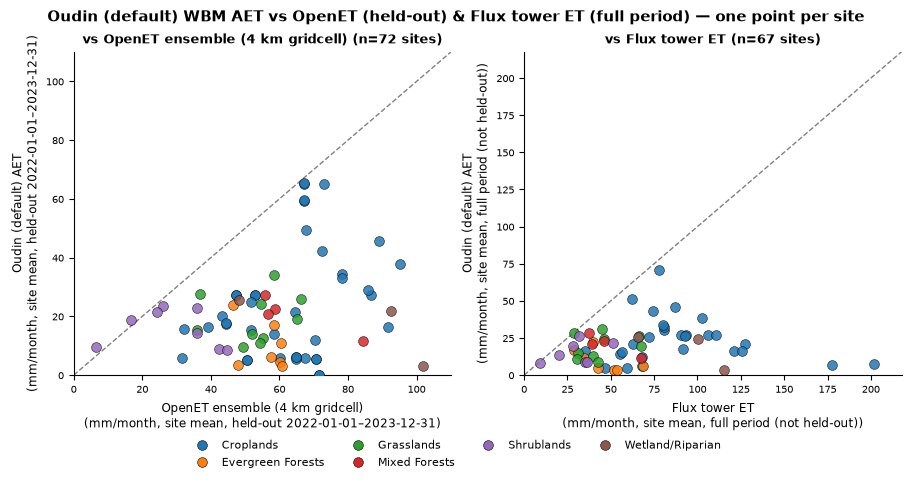

Saved to ../Data/pet_comparison/scatter_summary_oudin.png


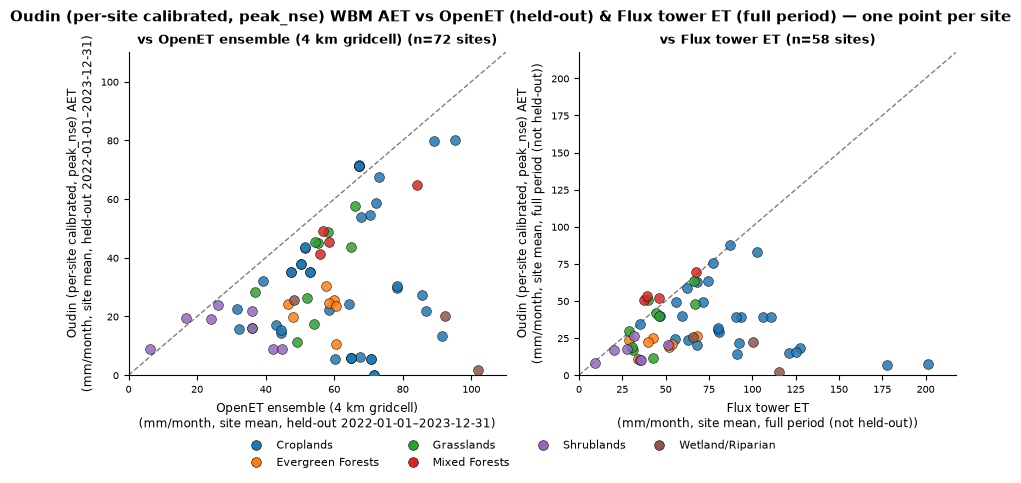

Saved to ../Data/pet_comparison/scatter_summary_oudin_cal.png


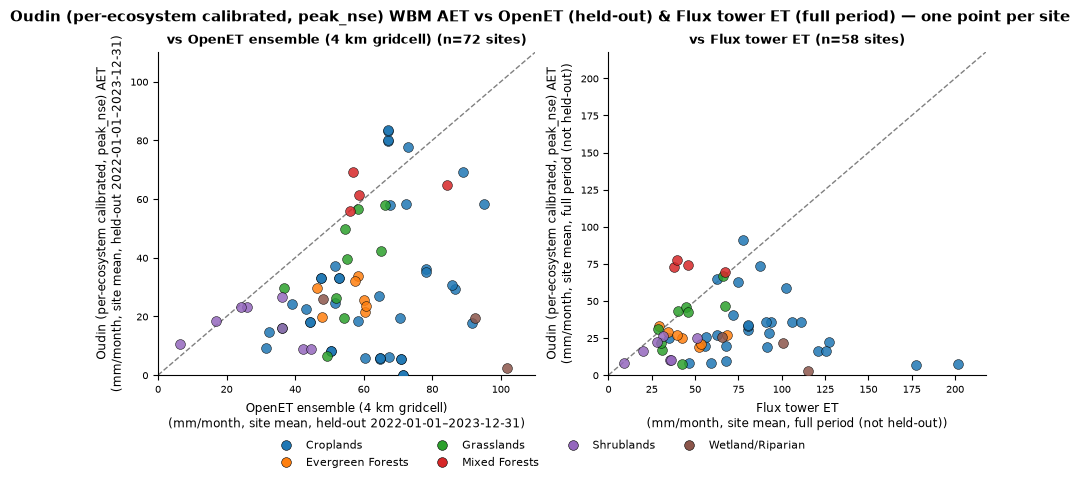

Saved to ../Data/pet_comparison/scatter_summary_oudin_eco_cal.png


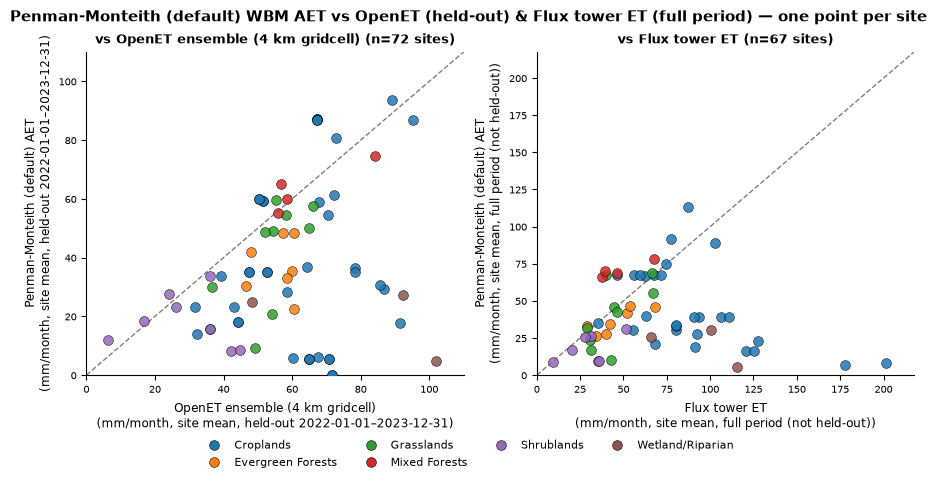

Saved to ../Data/pet_comparison/scatter_summary_pm.png


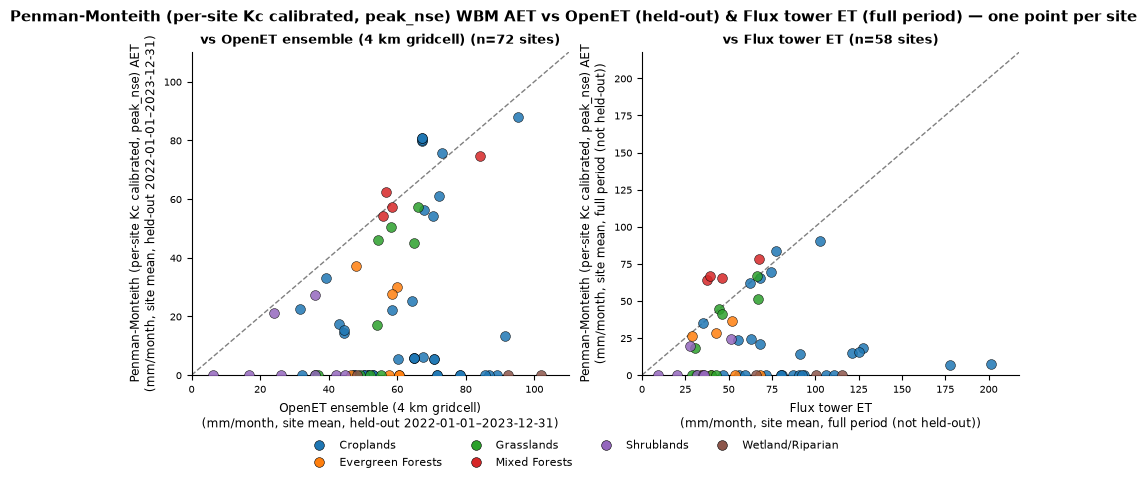

Saved to ../Data/pet_comparison/scatter_summary_pm_cal.png


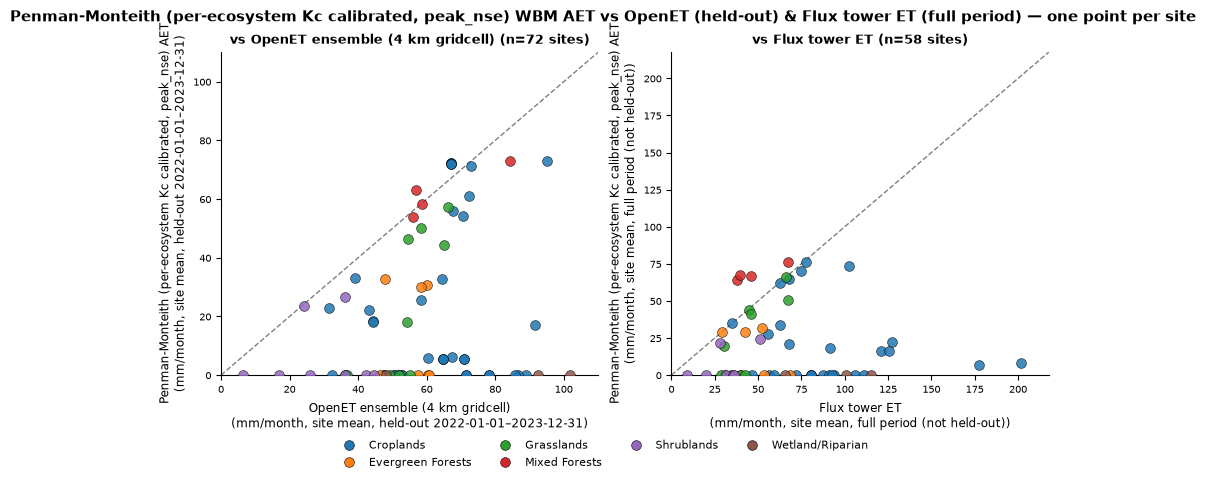

Saved to ../Data/pet_comparison/scatter_summary_pm_eco_cal.png


In [6]:
# ── Ecosystem color palette (shared across condensed figures below) ──────────
eco_lookup = combined[["site", "ecosystem"]].drop_duplicates()
ecosystems_all = sorted(eco_lookup["ecosystem"].dropna().unique())
_tab_colors = plt.cm.tab10.colors
ECO_COLORS = {eco: _tab_colors[i % 10] for i, eco in enumerate(ecosystems_all)}


def _site_means(matched_df, obs_col, pred_col, metrics_df, eco_lookup):
    """One row per site: site-mean obs/pred AET over the test period,
    restricted to sites with enough matched months per metrics_df (note == '')."""
    valid_sites = metrics_df.loc[metrics_df["note"] == "", "site"]
    return (
        matched_df[matched_df["site"].isin(valid_sites)]
        .groupby("site", as_index=False)[[obs_col, pred_col]]
        .mean()
        .merge(eco_lookup, on="site", how="left")
    )


def make_scatter_summary(openet_pts, flux_pts, obs_col_openet, obs_col_flux,
                          pred_col, method_label, save_path):
    """Condensed scatter for one AET method: one point per site (site-mean
    AET), colored by ecosystem, in two panels -- vs OpenET (held-out test
    period) and vs flux tower (full period -- see this notebook's banner for
    why the two panels use different windows)."""
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.3), constrained_layout=True)

    panels = [
        (axes[0], openet_pts, obs_col_openet, "OpenET ensemble (4 km gridcell)",
         f"site mean, held-out {TEST_START}\u2013{TEST_END}"),
        (axes[1], flux_pts,   obs_col_flux,   "Flux tower ET",
         "site mean, full period (not held-out)"),
    ]
    for ax, pts, obs_col, ref_label, period_note in panels:
        if pts.empty:
            ax.set_visible(False)
            continue
        for eco, grp in pts.groupby("ecosystem"):
            ax.scatter(grp[obs_col], grp[pred_col], s=50,
                       color=ECO_COLORS.get(eco, "grey"),
                       edgecolors="k", linewidths=0.4, alpha=0.85,
                       label=eco, zorder=3)
        lims = [0, max(pts[obs_col].max(), pts[pred_col].max()) * 1.08]
        ax.plot(lims, lims, color="grey", linestyle="--", linewidth=1, zorder=1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel(f"{ref_label}\n(mm/month, {period_note})", fontsize=8.5)
        ax.set_ylabel(f"{method_label} AET\n(mm/month, {period_note})", fontsize=8.5)
        ax.set_title(f"vs {ref_label} (n={len(pts)} sites)", fontsize=9.5, fontweight="bold")
        ax.tick_params(labelsize=7.5)
        ax.spines[["top", "right"]].set_visible(False)

    handles = [
        mlines.Line2D([], [], marker="o", linestyle="", markersize=7,
                      markerfacecolor=ECO_COLORS[e], markeredgecolor="k",
                      markeredgewidth=0.4, label=e)
        for e in ecosystems_all
    ]
    fig.legend(handles=handles, loc="lower center",
               ncol=min(len(ecosystems_all), 4),
               bbox_to_anchor=(0.5, -0.1), fontsize=8, frameon=False)
    fig.suptitle(f"{method_label} WBM AET vs OpenET (held-out) & Flux tower ET (full period) "
                 f"\u2014 one point per site",
                 fontsize=11, fontweight="bold")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")


SCATTER_METHODS = [
    ("aet_oudin_mm",         VARIANT_LABELS["oudin"],
     metrics_oudin_vs_openet, metrics_oudin_vs_flux,
     "../Data/pet_comparison/scatter_summary_oudin.png"),
    ("aet_oudin_cal_mm",     VARIANT_LABELS["oudin_cal"],
     metrics_oudin_cal_vs_openet, metrics_oudin_cal_vs_flux,
     "../Data/pet_comparison/scatter_summary_oudin_cal.png"),
    ("aet_oudin_eco_cal_mm", VARIANT_LABELS["oudin_eco_cal"],
     metrics_oudin_eco_cal_vs_openet, metrics_oudin_eco_cal_vs_flux,
     "../Data/pet_comparison/scatter_summary_oudin_eco_cal.png"),
    ("aet_pm_mm",            VARIANT_LABELS["pm"],
     metrics_pm_vs_openet, metrics_pm_vs_flux,
     "../Data/pet_comparison/scatter_summary_pm.png"),
    ("aet_pm_cal_mm",        VARIANT_LABELS["pm_cal"],
     metrics_pm_cal_vs_openet, metrics_pm_cal_vs_flux,
     "../Data/pet_comparison/scatter_summary_pm_cal.png"),
    ("aet_pm_eco_cal_mm",    VARIANT_LABELS["pm_eco_cal"],
     metrics_pm_eco_cal_vs_openet, metrics_pm_eco_cal_vs_flux,
     "../Data/pet_comparison/scatter_summary_pm_eco_cal.png"),
]

for pred_col, method_label, m_openet, m_flux, save_path in SCATTER_METHODS:
    openet_pts = _site_means(combined_test, "et_ensemble_gc_mm", pred_col, m_openet, eco_lookup)
    flux_pts   = _site_means(combined_ts, "aet_flux_mm", pred_col, m_flux, eco_lookup)
    make_scatter_summary(
        openet_pts, flux_pts,
        obs_col_openet="et_ensemble_gc_mm", obs_col_flux="aet_flux_mm",
        pred_col=pred_col, method_label=method_label, save_path=save_path,
    )


Mean RMSE vs OpenET by ecosystem (mm/month, held-out 2022-01-01–2023-12-31):
        ecosystem  RMSE_oudin  RMSE_oudin_cal  RMSE_oudin_eco_cal  RMSE_pm  RMSE_pm_cal  RMSE_pm_eco_cal
        Croplands       48.81           40.07               47.08    44.59        55.31            55.39
Evergreen Forests       55.75           39.81               42.86    38.86        54.99            55.02
       Grasslands       40.81           25.71               31.07    28.03        41.31            41.34
    Mixed Forests       55.39           22.86               43.27    28.62        27.73            27.64
       Shrublands       19.71           19.09               21.27    23.81        27.84            27.92
 Wetland/Riparian       76.21           76.29               76.05    78.04        92.55            92.55


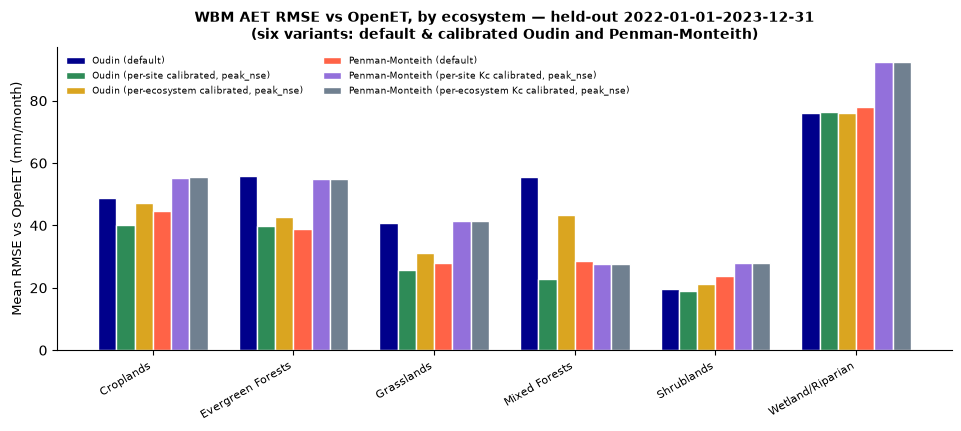

Saved to Data/pet_comparison/rmse_by_ecosystem_all_variants.png


In [7]:
eco_lookup = combined[["site", "ecosystem"]].drop_duplicates()

eco_rmse = (
    metrics_oudin_vs_openet[metrics_oudin_vs_openet["note"] == ""]
    [["site", "RMSE"]].rename(columns={"RMSE": "RMSE_oudin"})
    .merge(
        metrics_oudin_cal_vs_openet[metrics_oudin_cal_vs_openet["note"] == ""]
        [["site", "RMSE"]].rename(columns={"RMSE": "RMSE_oudin_cal"}),
        on="site", how="outer"
    )
    .merge(
        metrics_oudin_eco_cal_vs_openet[metrics_oudin_eco_cal_vs_openet["note"] == ""]
        [["site", "RMSE"]].rename(columns={"RMSE": "RMSE_oudin_eco_cal"}),
        on="site", how="outer"
    )
    .merge(
        metrics_pm_vs_openet[metrics_pm_vs_openet["note"] == ""]
        [["site", "RMSE"]].rename(columns={"RMSE": "RMSE_pm"}),
        on="site", how="outer"
    )
    .merge(
        metrics_pm_cal_vs_openet[metrics_pm_cal_vs_openet["note"] == ""]
        [["site", "RMSE"]].rename(columns={"RMSE": "RMSE_pm_cal"}),
        on="site", how="outer"
    )
    .merge(
        metrics_pm_eco_cal_vs_openet[metrics_pm_eco_cal_vs_openet["note"] == ""]
        [["site", "RMSE"]].rename(columns={"RMSE": "RMSE_pm_eco_cal"}),
        on="site", how="outer"
    )
    .merge(eco_lookup, on="site", how="left")
)

RMSE_ECO_COLS = ["RMSE_oudin", "RMSE_oudin_cal", "RMSE_oudin_eco_cal",
                  "RMSE_pm", "RMSE_pm_cal", "RMSE_pm_eco_cal"]

eco_summary = (
    eco_rmse.groupby("ecosystem")[RMSE_ECO_COLS]
    .mean().round(2).reset_index()
)
print(f"Mean RMSE vs OpenET by ecosystem (mm/month, held-out {TEST_START}\u2013{TEST_END}):")
print(eco_summary.to_string(index=False))

ecosystems = eco_summary["ecosystem"].tolist()
x = np.arange(len(ecosystems))
w = 0.13

BAR_COLORS = {
    "RMSE_oudin":         "darkblue",
    "RMSE_oudin_cal":     "seagreen",
    "RMSE_oudin_eco_cal": "goldenrod",
    "RMSE_pm":            "tomato",
    "RMSE_pm_cal":        "mediumpurple",
    "RMSE_pm_eco_cal":    "slategrey",
}
BAR_LABELS = {
    "RMSE_oudin":         VARIANT_LABELS["oudin"],
    "RMSE_oudin_cal":     VARIANT_LABELS["oudin_cal"],
    "RMSE_oudin_eco_cal": VARIANT_LABELS["oudin_eco_cal"],
    "RMSE_pm":            VARIANT_LABELS["pm"],
    "RMSE_pm_cal":        VARIANT_LABELS["pm_cal"],
    "RMSE_pm_eco_cal":    VARIANT_LABELS["pm_eco_cal"],
}

fig, ax = plt.subplots(figsize=(9.5, 4.2), constrained_layout=True)
offsets = np.linspace(-2.5, 2.5, len(RMSE_ECO_COLS)) * w
for col, off in zip(RMSE_ECO_COLS, offsets):
    ax.bar(x + off, eco_summary[col], width=w, color=BAR_COLORS[col],
           label=BAR_LABELS[col], edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(ecosystems, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Mean RMSE vs OpenET (mm/month)", fontsize=9)
ax.set_title(f"WBM AET RMSE vs OpenET, by ecosystem \u2014 held-out {TEST_START}\u2013{TEST_END}\n"
             "(six variants: default & calibrated Oudin and Penman-Monteith)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=6.8, frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.savefig("../Data/pet_comparison/rmse_by_ecosystem_all_variants.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Data/pet_comparison/rmse_by_ecosystem_all_variants.png")


### Step 5 — Example timeseries: best / median / worst site, ranked on held-out skill

Monthly AET timeseries (OpenET, all six WBM runs, flux tower) for three
representative sites instead of a facet per site: ranked by the per-site-
calibrated Oudin variant's **held-out test-period** RMSE vs. OpenET (this
notebook's most-established calibrated configuration prior to this pass),
picking the best-fit, median-fit, and worst-fit site. The plot itself still
shows the *full* 2016–2023 record with a shaded calibration window, so you
can see how each method behaves both during and after the period it was (or
wasn't) fit to. Full per-site facets remain available at the smaller
park-proximity scale in notebook 09.

Example sites (ranked by held-out per-site-calibrated-Oudin RMSE vs OpenET, n=72 valid sites, test period 2022-01-01–2023-12-31):
  Best fit   : US-xJR  (RMSE=7.44 mm/month)
  Median fit : manilacotton  (RMSE=28.69 mm/month)
  Worst fit  : US-Sne  (RMSE=116.54 mm/month)


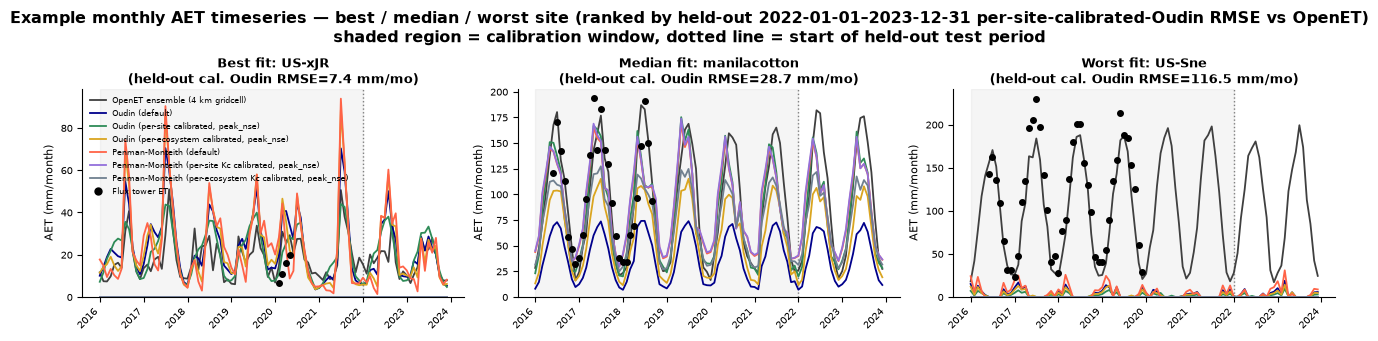

Saved to Data/pet_comparison/timeseries_examples_best_median_worst.png


In [8]:
# ── Condensed example timeseries: best / median / worst site by held-out RMSE ──
_valid_rank = (
    metrics_oudin_cal_vs_openet[metrics_oudin_cal_vs_openet["note"] == ""]
    .sort_values("RMSE")
    .reset_index(drop=True)
)
_n = len(_valid_rank)
if _n == 0:
    raise RuntimeError("No sites with valid held-out per-site-calibrated-Oudin RMSE vs "
                       "OpenET -- can't pick example sites.")

example_sites = [
    (_valid_rank.iloc[0]["site"],        "Best fit",   _valid_rank.iloc[0]["RMSE"]),
    (_valid_rank.iloc[_n // 2]["site"],  "Median fit", _valid_rank.iloc[_n // 2]["RMSE"]),
    (_valid_rank.iloc[-1]["site"],       "Worst fit",  _valid_rank.iloc[-1]["RMSE"]),
]
print(f"Example sites (ranked by held-out per-site-calibrated-Oudin RMSE vs OpenET, "
      f"n={_n} valid sites, test period {TEST_START}\u2013{TEST_END}):")
for site, label, rmse in example_sites:
    print(f"  {label:<10} : {site}  (RMSE={rmse:.2f} mm/month)")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3), sharey=False, constrained_layout=True)
axes = np.atleast_1d(axes)

_cal_start_dt  = pd.Timestamp(CAL_START)
_test_start_dt = pd.Timestamp(TEST_START)

PLOT_SPECS = [
    ("et_ensemble_gc_mm",   "#3f3f3f",     "OpenET ensemble (4 km gridcell)", 3),
    ("aet_oudin_mm",        "darkblue",    VARIANT_LABELS["oudin"],           4),
    ("aet_oudin_cal_mm",    "seagreen",    VARIANT_LABELS["oudin_cal"],       4.5),
    ("aet_oudin_eco_cal_mm","goldenrod",   VARIANT_LABELS["oudin_eco_cal"],   4.7),
    ("aet_pm_mm",           "tomato",      VARIANT_LABELS["pm"],              5),
    ("aet_pm_cal_mm",       "mediumpurple",VARIANT_LABELS["pm_cal"],          5.2),
    ("aet_pm_eco_cal_mm",   "slategrey",   VARIANT_LABELS["pm_eco_cal"],      5.4),
]

for ax, (site, label, rmse) in zip(axes, example_sites):
    sub = combined_ts[combined_ts["site"] == site].sort_values("date")

    # Shade the calibration window so it's visually clear which part of the
    # record any calibrated line was fit to -- everything to the right of the
    # dashed line (TEST_START) is what the RMSE above is actually computed on.
    ax.axvspan(_cal_start_dt, _test_start_dt, color="grey", alpha=0.08, zorder=0)
    ax.axvline(_test_start_dt, color="grey", linestyle=":", linewidth=1, zorder=2)

    for col, color, plabel, z in PLOT_SPECS:
        ax.plot(sub["date"], sub[col], color=color, linewidth=1.3,
                 linestyle="-", label=plabel, zorder=z)

    flux_sub = sub.dropna(subset=["aet_flux_mm"])
    if not flux_sub.empty:
        ax.scatter(flux_sub["date"], flux_sub["aet_flux_mm"],
                   color="black", s=16, zorder=8, label="Flux tower ET")

    ax.set_title(f"{label}: {site}\n(held-out cal. Oudin RMSE={rmse:.1f} mm/mo)",
                 fontsize=9.5, fontweight="bold", pad=4)
    ax.set_ylabel("AET (mm/month)", fontsize=8)
    ax.tick_params(axis="both", labelsize=7.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

axes[0].legend(
    handles=[mlines.Line2D([], [], color=color, linewidth=1.3, label=plabel)
             for _, color, plabel, _ in PLOT_SPECS]
    + [mlines.Line2D([], [], color="black", linewidth=0, marker="o", markersize=5,
                      label="Flux tower ET")],
    loc="upper left", fontsize=5.8, frameon=False,
)

fig.suptitle(
    "Example monthly AET timeseries \u2014 best / median / worst site "
    f"(ranked by held-out {TEST_START}\u2013{TEST_END} per-site-calibrated-Oudin RMSE vs OpenET)\n"
    "shaded region = calibration window, dotted line = start of held-out test period",
    fontsize=11.5, fontweight="bold",
)
plt.savefig("../Data/pet_comparison/timeseries_examples_best_median_worst.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Data/pet_comparison/timeseries_examples_best_median_worst.png")


### Step 7 — Spatial map: which WBM AET variant matches OpenET best, by site?

For each site, finds whichever of the six variants (Oudin default/per-site/
per-ecosystem calibrated, Penman-Monteith default/per-site/per-ecosystem
calibrated) has the lowest **held-out test-period** RMSE vs. OpenET (from
Step 3), and maps that as a category, sized by how much better it is than
the runner-up at that site. This map shows the *locally* best variant per
site — useful for diagnosing where each method struggles, but remember this
notebook's actual recommendation is a single nationwide method (Step 3's
robustness summary), not "use whichever variant wins on this map at your
site."

This is an **interactive** Plotly map rather than a static one: it uses
Plotly's built-in USA state outlines (no shapefile download, so no
dependency on Census/GitHub being reachable), and hovering a point shows
its full metrics instead of a permanent text label -- which avoids the
overlapping-label problem the static version had at clustered sites (e.g.
the LYS_* and US-Ro* groups).

In [9]:
import plotly.graph_objects as go

# ── Merge each variant's held-out RMSE (vs OpenET) with site coordinates ─────
map_df = (
    metrics_oudin_vs_openet[metrics_oudin_vs_openet["note"] == ""][["site", "RMSE"]]
    .rename(columns={"RMSE": "RMSE_oudin"})
    .merge(
        metrics_oudin_cal_vs_openet[metrics_oudin_cal_vs_openet["note"] == ""][["site", "RMSE"]]
        .rename(columns={"RMSE": "RMSE_oudin_cal"}),
        on="site", how="inner"
    )
    .merge(
        metrics_oudin_eco_cal_vs_openet[metrics_oudin_eco_cal_vs_openet["note"] == ""][["site", "RMSE"]]
        .rename(columns={"RMSE": "RMSE_oudin_eco_cal"}),
        on="site", how="inner"
    )
    .merge(
        metrics_pm_vs_openet[metrics_pm_vs_openet["note"] == ""][["site", "RMSE"]]
        .rename(columns={"RMSE": "RMSE_pm"}),
        on="site", how="inner"
    )
    .merge(
        metrics_pm_cal_vs_openet[metrics_pm_cal_vs_openet["note"] == ""][["site", "RMSE"]]
        .rename(columns={"RMSE": "RMSE_pm_cal"}),
        on="site", how="inner"
    )
    .merge(
        metrics_pm_eco_cal_vs_openet[metrics_pm_eco_cal_vs_openet["note"] == ""][["site", "RMSE"]]
        .rename(columns={"RMSE": "RMSE_pm_eco_cal"}),
        on="site", how="inner"
    )
    .merge(flux_towers[["site", "x", "y", "ecosystem"]], on="site", how="left")
    .dropna(subset=["x", "y"])
    .reset_index(drop=True)
)

RMSE_COLS = ["RMSE_oudin", "RMSE_oudin_cal", "RMSE_oudin_eco_cal",
             "RMSE_pm", "RMSE_pm_cal", "RMSE_pm_eco_cal"]
METHOD_LABELS = {
    "RMSE_oudin":         VARIANT_LABELS["oudin"],
    "RMSE_oudin_cal":     VARIANT_LABELS["oudin_cal"],
    "RMSE_oudin_eco_cal": VARIANT_LABELS["oudin_eco_cal"],
    "RMSE_pm":            VARIANT_LABELS["pm"],
    "RMSE_pm_cal":        VARIANT_LABELS["pm_cal"],
    "RMSE_pm_eco_cal":    VARIANT_LABELS["pm_eco_cal"],
}
METHOD_COLORS = {
    VARIANT_LABELS["oudin"]:         "darkblue",
    VARIANT_LABELS["oudin_cal"]:     "seagreen",
    VARIANT_LABELS["oudin_eco_cal"]: "goldenrod",
    VARIANT_LABELS["pm"]:            "tomato",
    VARIANT_LABELS["pm_cal"]:        "mediumpurple",
    VARIANT_LABELS["pm_eco_cal"]:    "slategrey",
}

best_col = map_df[RMSE_COLS].idxmin(axis=1)
map_df["best_method"] = best_col.map(METHOD_LABELS)
map_df["best_RMSE"]   = map_df[RMSE_COLS].min(axis=1)
sorted_vals = map_df[RMSE_COLS].apply(lambda r: sorted(r.values), axis=1)
map_df["margin"] = sorted_vals.apply(lambda v: v[1] - v[0])

print(f"Sites mapped (held-out {TEST_START}\u2013{TEST_END}): {len(map_df)}")
print(map_df[["site", "ecosystem"] + RMSE_COLS + ["best_method", "margin"]]
      .round(2).to_string(index=False))
print()
print("Sites where each variant is best (locally, held-out test period):")
print(map_df["best_method"].value_counts().to_string())

# ── Interactive Plotly map -- scope="usa" draws state outlines from Plotly's
# own bundled map data, so this needs no shapefile download at all ───────────
max_margin = max(map_df["margin"].max(), 1)

fig = go.Figure()
for method, color in METHOD_COLORS.items():
    sub = map_df[map_df["best_method"] == method]
    if sub.empty:
        continue
    sizes = (sub["margin"] / max_margin * 26).clip(lower=6)
    hover_text = [
        f"<b>{row.site}</b> ({row.ecosystem})<br>"
        f"Oudin (default): {row.RMSE_oudin:.1f} mm/mo<br>"
        f"Oudin (per-site cal.): {row.RMSE_oudin_cal:.1f} mm/mo<br>"
        f"Oudin (per-ecosystem cal.): {row.RMSE_oudin_eco_cal:.1f} mm/mo<br>"
        f"Penman-Monteith (default): {row.RMSE_pm:.1f} mm/mo<br>"
        f"Penman-Monteith (per-site cal.): {row.RMSE_pm_cal:.1f} mm/mo<br>"
        f"Penman-Monteith (per-ecosystem cal.): {row.RMSE_pm_eco_cal:.1f} mm/mo<br>"
        f"Best: {row.best_method} (margin {row.margin:.1f} mm/mo)"
        for row in sub.itertuples()
    ]
    fig.add_trace(go.Scattergeo(
        lon=sub["x"], lat=sub["y"],
        mode="markers",
        name=method,
        marker=dict(size=sizes, color=color, line=dict(width=1, color="black"), opacity=0.85),
        text=hover_text,
        hoverinfo="text",
    ))

fig.update_geos(
    scope="usa",
    showland=True, landcolor="whitesmoke",
    showlakes=True, lakecolor="white",
    subunitcolor="grey", subunitwidth=0.6,
    countrycolor="grey",
)
fig.update_layout(
    title=f"Which WBM AET variant matches OpenET best, by site? (held-out {TEST_START}\u2013{TEST_END})"
          "<br><sup>marker size \u221d margin over the runner-up -- hover for per-site RMSE</sup>",
    legend_title_text="Best-matching variant (locally)",
    margin=dict(l=0, r=0, t=60, b=0),
    height=550,
)

os.makedirs("../Data/pet_comparison", exist_ok=True)
fig.write_html("../Data/pet_comparison/map_best_method_vs_openet.html")
print("Saved interactive map to Data/pet_comparison/map_best_method_vs_openet.html")

# Best-effort static PNG too (needs kaleido + a local Chrome install; skipped
# gracefully if unavailable so this cell never fails because of it).
try:
    fig.write_image("../Data/pet_comparison/map_best_method_vs_openet.png",
                     width=1000, height=650, scale=2)
    print("Saved static PNG to Data/pet_comparison/map_best_method_vs_openet.png")
except Exception as e:
    print(f"(skipped static PNG export -- {e})")

fig.show()


Sites mapped (held-out 2022-01-01–2023-12-31): 72
         site         ecosystem  RMSE_oudin  RMSE_oudin_cal  RMSE_oudin_eco_cal  RMSE_pm  RMSE_pm_cal  RMSE_pm_eco_cal                                             best_method  margin
ALARC2_Smith6         Croplands       71.98           71.54               72.26    72.23        71.52            72.02      Penman-Monteith (per-site Kc calibrated, peak_nse)    0.02
  Almond_High         Croplands       31.49           33.46               33.45    36.38        33.30            33.54                                         Oudin (default)    1.81
   Almond_Low         Croplands       29.37           28.89               33.51    36.94        28.87            32.72      Penman-Monteith (per-site Kc calibrated, peak_nse)    0.03
   Almond_Med         Croplands       30.98           32.67               32.96    35.67        32.54            33.01                                         Oudin (default)    1.56
       BAR012         Croplands    

### Summary & suggested follow-ups

This benchmarks six WBM AET variants against OpenET and flux tower ET,
**on a genuinely held-out 2022–2023 test period** that no calibration ever
saw: default (uncalibrated) Oudin, notebook 04's per-site PET-multiplier-
calibrated Oudin, notebook 04's per-ecosystem pooled-calibration Oudin,
(uncalibrated) Penman-Monteith, notebook 07's per-site `Kc`-calibrated
Penman-Monteith, and notebook 07's per-ecosystem pooled-`Kc`-calibration
Penman-Monteith. Step 3's robustness summary tables
(`robustness_summary_vs_openet.csv` / `_vs_flux.csv`) — mean, median, and
worst-decile RMSE per variant — are the headline output for choosing a
single nationwide method; the per-site map in Step 7 is diagnostic (where
each variant struggles), not a recommendation to vary methods by site.

**Natural follow-ups:**
- Run the same paired-significance testing already used for the four-variant
  comparison (Wilcoxon signed-rank on per-site RMSE, Holm-Bonferroni
  corrected) across all six variants now that both PM-calibrated caches
  exist, and update the report's Table 2 and Discussion/Conclusion
  accordingly if the nationwide recommendation changes.
- Check sensitivity to the 2016–2021 / 2022–2023 split itself — e.g. a
  different split, or k-fold-style rotation across years, would show whether
  the robustness ranking here is an artifact of which years landed in the
  test set.
- If a different calibration objective is preferred, re-run notebooks 04 and
  07 with a different `OBJECTIVE` (both notebooks' per-site and
  per-ecosystem cells) before re-running this notebook — Step 0 picks up
  whatever `OBJECTIVE`/`OBJECTIVE_PM` each notebook was last cached with, and
  warns if they've drifted apart.
- This notebook's figures are condensed for the full nationwide site list
  (site-mean scatter colored by ecosystem, best/median/worst example
  timeseries) rather than faceted per site. For full per-site facets at the
  smaller park-proximity scale, see notebook 09.
- Notebook 10 (runoff implications) still only covers the original four
  variants -- extending it to include the two PM-calibrated variants would
  complete the water-balance-implications picture to match this notebook.
